No images found in /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/raw/celeba
Starting automatic Kaggle download for CelebA...
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset


100%|██████████| 1.33G/1.33G [00:00<00:00, 1.66GB/s]



Kaggle download finished.
Moving image files into /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/raw/celeba ...
Finished. hardlinked=202599, copied=0, skipped=0
{
  "master_csv": "/data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/manifests/celeba_master.csv",
  "train_csv": "/data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/manifests/split_train.csv",
  "val_csv": "/data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/manifests/split_val.csv",
  "test_csv": "/data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/manifests/split_test.csv",
  "num_images_total": 202599,
  "num_train": 182339,
  "num_val": 10129,
  "num_test": 10131,
  "celeba_dir": "/data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/raw/celeba",
  "downloads_dir": "/data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/data/_downloads/celeba_kaggle"
}


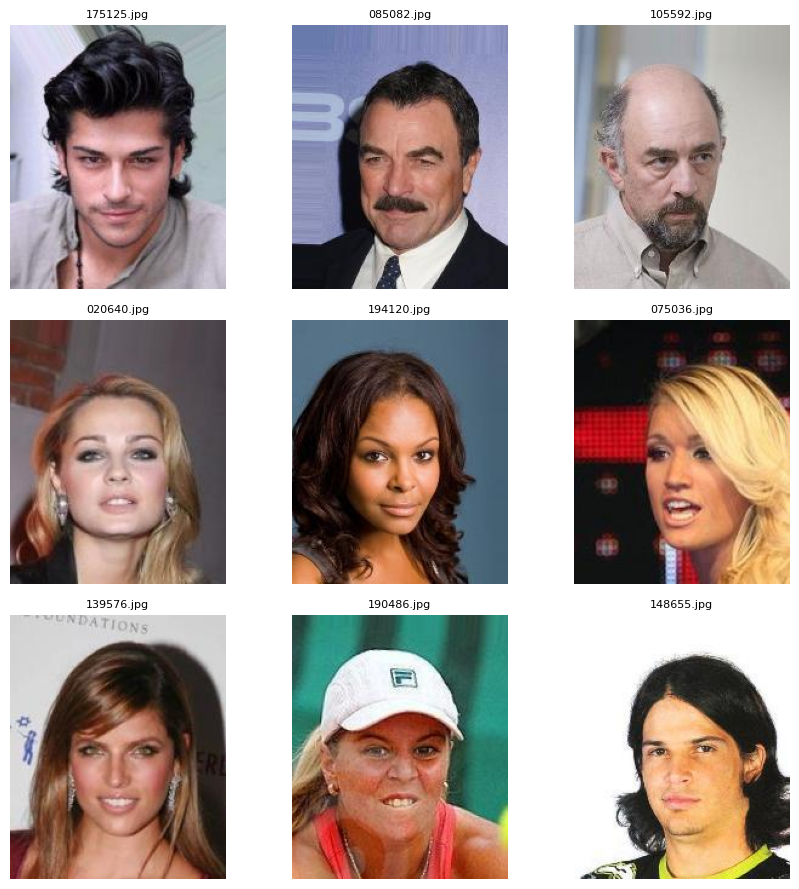

\nNotebook 02 complete.
Next notebook: 03_face_alignment_and_quality_audit.ipynb


In [2]:
from pathlib import Path
import os, sys, subprocess, zipfile, shutil, random, json
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# =========================================================
# PASTE YOUR KAGGLE CREDENTIALS HERE
# =========================================================
KAGGLE_USERNAME = "sajjancodes"
KAGGLE_KEY = "KGAT_0bcd61b1e231fdc00b951f09400acbd0"

# =========================================================
# PATH SETUP
# =========================================================
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
celeba_dir = ROOT / "data" / "raw" / "celeba"
downloads_dir = ROOT / "data" / "_downloads" / "celeba_kaggle"
manifests_dir = ROOT / "data" / "manifests"

celeba_dir.mkdir(parents=True, exist_ok=True)
downloads_dir.mkdir(parents=True, exist_ok=True)
manifests_dir.mkdir(parents=True, exist_ok=True)

# =========================================================
# INSTALL REQUIRED PACKAGES
# =========================================================
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "kaggle", "pandas", "matplotlib", "pillow"],
    check=True
)

# =========================================================
# SET KAGGLE AUTH VIA ENV VARS
# =========================================================
if not KAGGLE_USERNAME or "PASTE_YOUR_KAGGLE_USERNAME_HERE" in KAGGLE_USERNAME:
    raise ValueError("Please set KAGGLE_USERNAME at the top of this cell.")
if not KAGGLE_KEY or "PASTE_YOUR_KAGGLE_API_KEY_HERE" in KAGGLE_KEY:
    raise ValueError("Please set KAGGLE_KEY at the top of this cell.")

os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"] = KAGGLE_KEY

# =========================================================
# HELPERS
# =========================================================
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

def list_images(folder: Path):
    return [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

def build_image_manifest(image_dir: Path):
    rows = []
    for p in sorted(list_images(image_dir)):
        rows.append({
            "image_id": p.stem,
            "file_path": str(p.resolve()),
            "suffix": p.suffix.lower()
        })
    return pd.DataFrame(rows)

def make_random_splits(df, train_frac=0.90, val_frac=0.05, seed=42):
    import numpy as np
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df))
    rng.shuffle(idx)
    n = len(df)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]
    return df.iloc[train_idx].copy(), df.iloc[val_idx].copy(), df.iloc[test_idx].copy()

def download_celeba_from_kaggle():
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()

    dataset_handle = "jessicali9530/celeba-dataset"
    print(f"Downloading {dataset_handle} into {downloads_dir} ...")
    api.dataset_download_files(
        dataset_handle,
        path=str(downloads_dir),
        unzip=True,
        quiet=False
    )
    print("Kaggle download finished.")

def extract_nested_zips_if_any():
    zips = sorted(downloads_dir.rglob("*.zip"))
    if len(zips) > 0:
        print(f"Found {len(zips)} nested zip file(s). Extracting them...")
    for z in zips:
        try:
            with zipfile.ZipFile(z, "r") as zf:
                zf.extractall(downloads_dir)
            print(f"Extracted: {z}")
        except Exception as e:
            print(f"Skipping {z} due to error: {e}")

def populate_raw_celeba_from_downloads():
    downloaded_images = list_images(downloads_dir)
    if len(downloaded_images) == 0:
        raise RuntimeError(
            f"No images found after download inside {downloads_dir}. "
            f"Open that folder and inspect what was downloaded."
        )

    existing = list_images(celeba_dir)
    if len(existing) > 0:
        print(f"data/raw/celeba already contains {len(existing)} images. Skipping copy.")
        return

    copied = 0
    linked = 0
    skipped = 0

    print(f"Moving image files into {celeba_dir} ...")
    for src in downloaded_images:
        dst = celeba_dir / src.name
        if dst.exists():
            skipped += 1
            continue
        try:
            os.link(src, dst)   # fast if same filesystem
            linked += 1
        except Exception:
            shutil.copy2(src, dst)
            copied += 1

    print(f"Finished. hardlinked={linked}, copied={copied}, skipped={skipped}")

# =========================================================
# AUTO-DOWNLOAD IF EMPTY
# =========================================================
existing_images = list_images(celeba_dir)

if len(existing_images) == 0:
    print(f"No images found in {celeba_dir}")
    print("Starting automatic Kaggle download for CelebA...")
    download_celeba_from_kaggle()
    extract_nested_zips_if_any()
    populate_raw_celeba_from_downloads()
else:
    print(f"Found {len(existing_images)} images already in {celeba_dir}. No download needed.")

# =========================================================
# BUILD MANIFEST + SPLITS
# =========================================================
df = build_image_manifest(celeba_dir)
assert len(df) > 0, f"No images found in {celeba_dir} even after download."

df["split"] = "unset"
master_path = manifests_dir / "celeba_master.csv"
df.to_csv(master_path, index=False)

train_df, val_df, test_df = make_random_splits(df, train_frac=0.90, val_frac=0.05, seed=42)
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

train_path = manifests_dir / "split_train.csv"
val_path = manifests_dir / "split_val.csv"
test_path = manifests_dir / "split_test.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

summary = {
    "master_csv": str(master_path),
    "train_csv": str(train_path),
    "val_csv": str(val_path),
    "test_csv": str(test_path),
    "num_images_total": int(len(df)),
    "num_train": int(len(train_df)),
    "num_val": int(len(val_df)),
    "num_test": int(len(test_df)),
    "celeba_dir": str(celeba_dir),
    "downloads_dir": str(downloads_dir),
}
(manifests_dir / "dataset_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(json.dumps(summary, indent=2))

# =========================================================
# QUICK VISUAL CHECK
# =========================================================
sample_paths = random.sample(df["file_path"].tolist(), min(9, len(df)))
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, p in zip(axes.flat, sample_paths):
    img = Image.open(p).convert("RGB")
    ax.imshow(img)
    ax.set_title(Path(p).name[:18], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("\\nNotebook 02 complete.")
print("Next notebook: 03_face_alignment_and_quality_audit.ipynb")